# Pyforce Demo

Create geometry - $[0,1]^2$ domain.

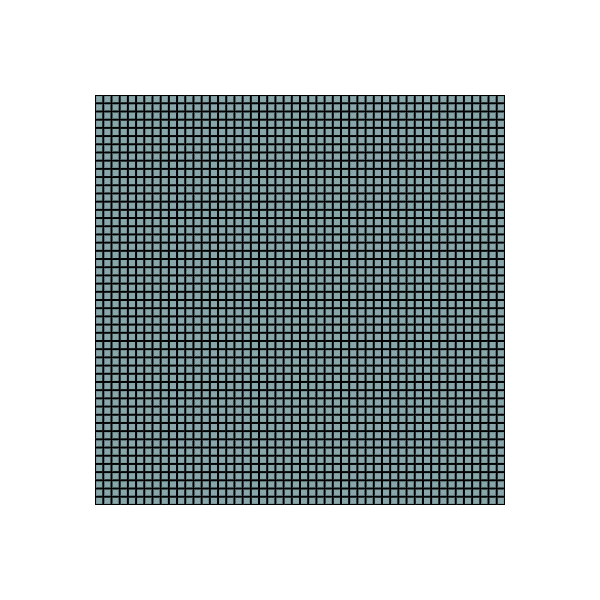

In [1]:
import pyvista as pv

nx = 50
ny = 50
nz = 1

grid = pv.ImageData(
    dimensions=(nx+1, ny+1, nz+1),
    spacing=(1/nx, 1/ny, 1e-4),
    origin=(0.0, 0.0, 0.0)
)

# 2. Plot the grid
plotter = pv.Plotter()
plotter.add_mesh(grid, show_edges=True, color='lightblue', line_width=2)
plotter.view_xy()  # Set the camera to look at the XY plane
plotter.show(jupyter_backend='static', window_size=[600, 600])

Define the snapshots considering this toy function:

In [2]:
from pyforce.tools.functions_list import FunctionsList
import numpy as np

X, Y = grid.points[:, 0], grid.points[:, 1]

mu_values = np.linspace(-5, 5, 100)

def harmonic_oscillator(X, Y, mu):
    term1 = np.sin(mu * np.pi * X) * np.cos(np.pi * Y)
    term2 = np.cos(np.pi * X) * np.sin((1 - mu) * np.pi * Y**2)
    
    return term1 + term2

snapshots = FunctionsList(dofs=len(X))

for mu in mu_values:
    snapshot = harmonic_oscillator(X, Y, mu)
    snapshots.append(snapshot)

Plot the snapshots for a few parameter values.

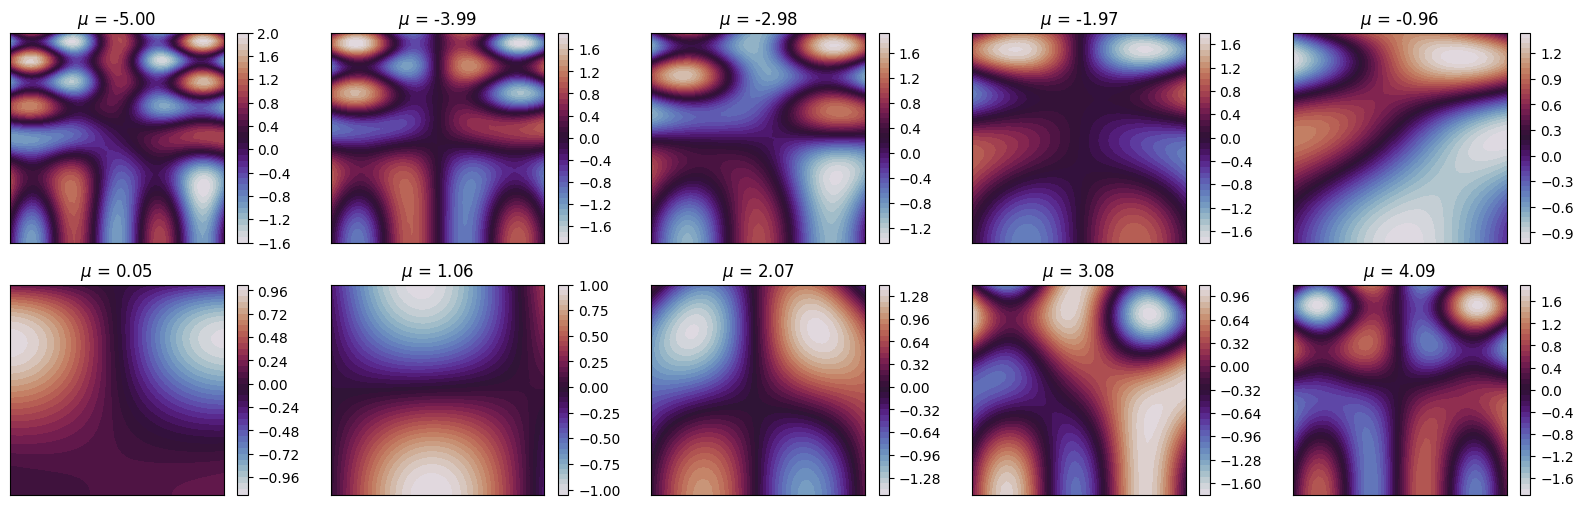

In [3]:

import matplotlib.pyplot as plt
fig, axs = plt.subplots(2,5, figsize=(4 * 5, 3 * 2))
axs = axs.ravel()

for ii, ax in enumerate(axs):
    
    mu_to_plot = mu_values[ii*10]
    c = ax.tricontourf(X, Y, snapshots[ii*10], levels=40, cmap='twilight')
    ax.set_title(f"$\mu$ = {mu_to_plot:.2f}")
    fig.colorbar(c, ax=ax)

    ax.set_xticks([])
    ax.set_yticks([])

fig.savefig("pyforce_demo_snapshots.png", dpi=300, bbox_inches='tight')

Separate training and test sets.

In [4]:
from pyforce.tools.functions_list import train_test_split

train_mu, test_mu, train_snaps, test_snaps = train_test_split(mu_values, snapshots, test_size=0.2, random_state=42)

## SVD

Perform rSVD on the training snapshots and plot the singular values.

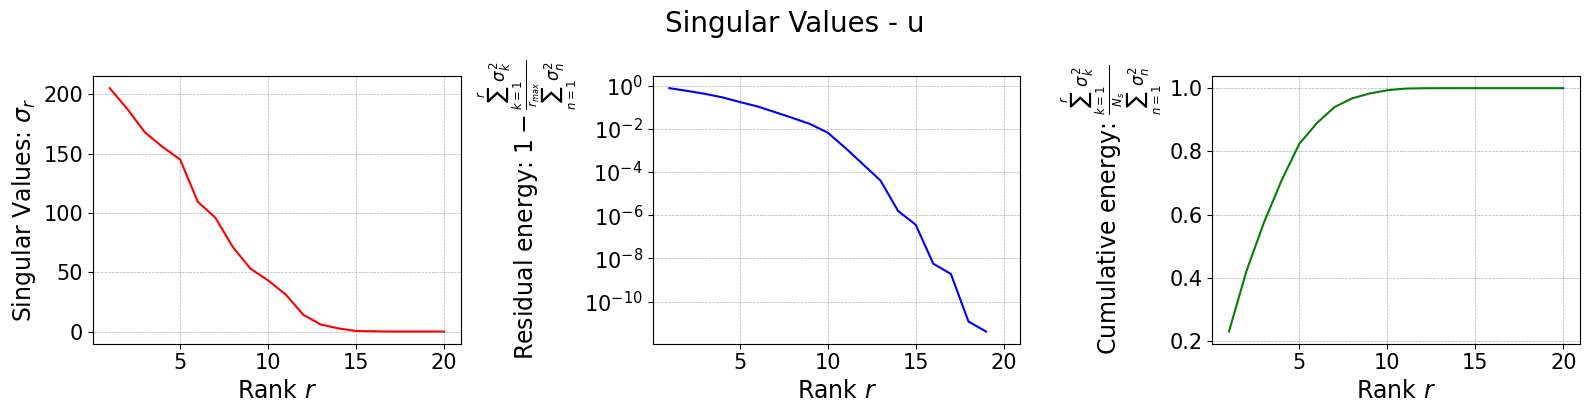

In [5]:
from pyforce.offline.pod import rSVD

svd = rSVD(grid, gdim = 3)
svd.fit(train_snaps, rank = 20)
eig_fig = svd.plot_sing_vals()
eig_fig.savefig("pyforce_demo_singular_values.png", dpi=300, bbox_inches='tight')

Plot the reduced coefficients as a function of the parameter values.

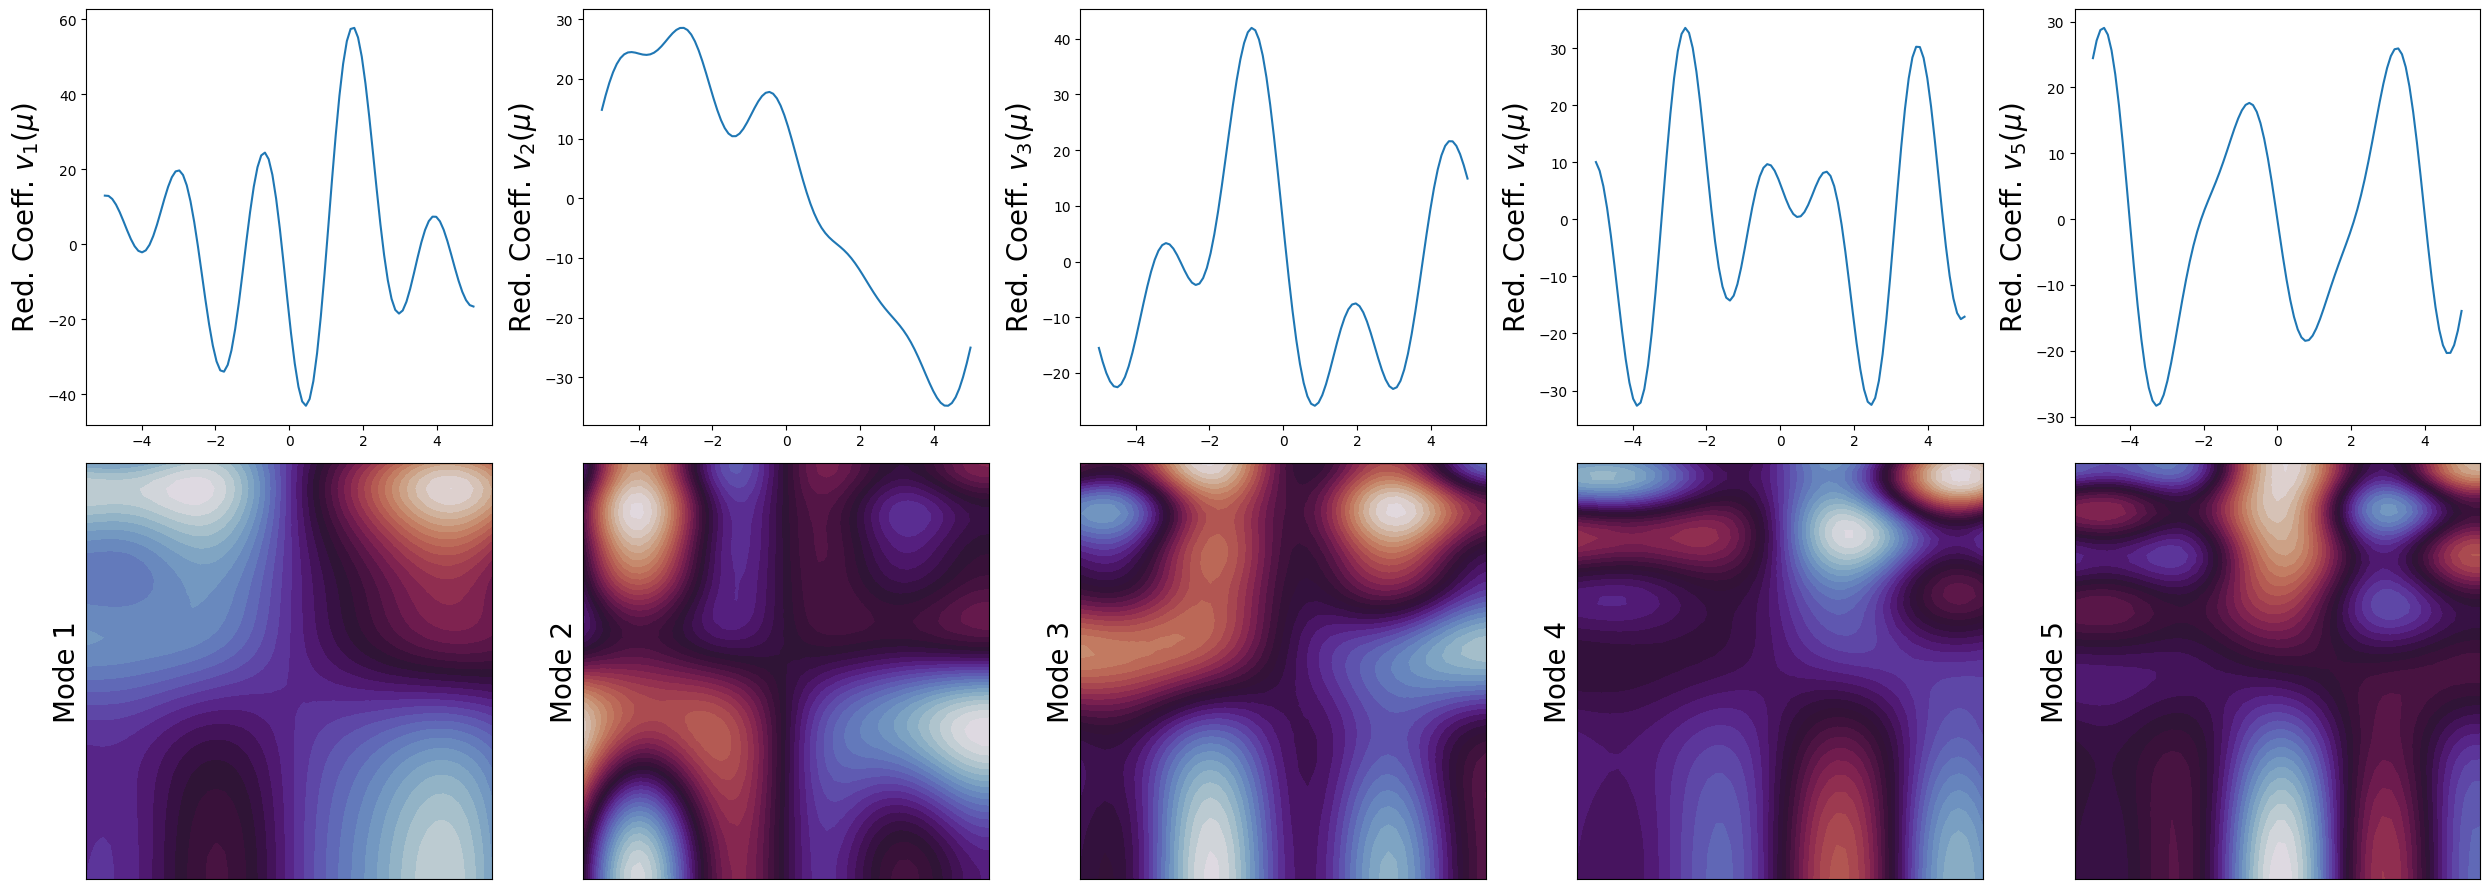

In [38]:
coeffs = svd.reduce(snapshots)

fig, axs = plt.subplots(2,5, figsize=(5 * 5, 4.5 * 2))

for ii in range(axs.shape[1]):
    
    axs[0, ii].plot(mu_values, coeffs[ii], '-')
    axs[1, ii].tricontourf(X, Y, svd.svd_modes[ii], levels=40, cmap='twilight')

    axs[0, ii].set_ylabel(f"Red. Coeff. $v_{ii+1}(\mu)$", fontsize=20)
    axs[1, ii].set_ylabel(f"Mode {ii+1}", fontsize=20)

for ax in axs[1]:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

## EIM
Perform EIM on the training snapshots and plot the interpolation points.

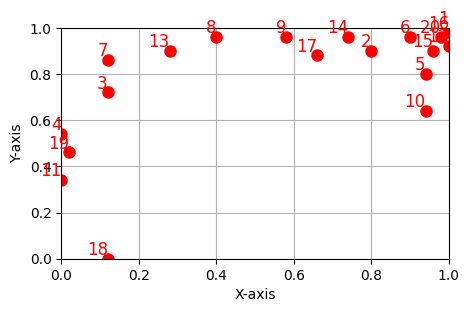

In [46]:
from pyforce.offline.eim import EIM

eim = EIM(grid, gdim = 3)
eim.fit(train_snaps, Mmax = 20)

magic_points = np.array(eim.magic_points['points'])

fig, axs = plt.subplots(1, 1, figsize=(5,3))

axs.plot(magic_points[:, 0], magic_points[:, 1], 'ro', markersize=8)
for ii, (x, y) in enumerate(magic_points[:, :2]):
    axs.text(x, y, f'{ii+1}', color='red', fontsize=12, ha='right', va='bottom')

axs.set_xlim(0, 1)
axs.set_ylim(0, 1)
axs.grid()
axs.set_xlabel('X-axis')
axs.set_ylabel('Y-axis')
fig.savefig("pyforce_demo_magic_points.png", dpi=300, bbox_inches='tight')

Plot the reduced dynamics and the basis functions.

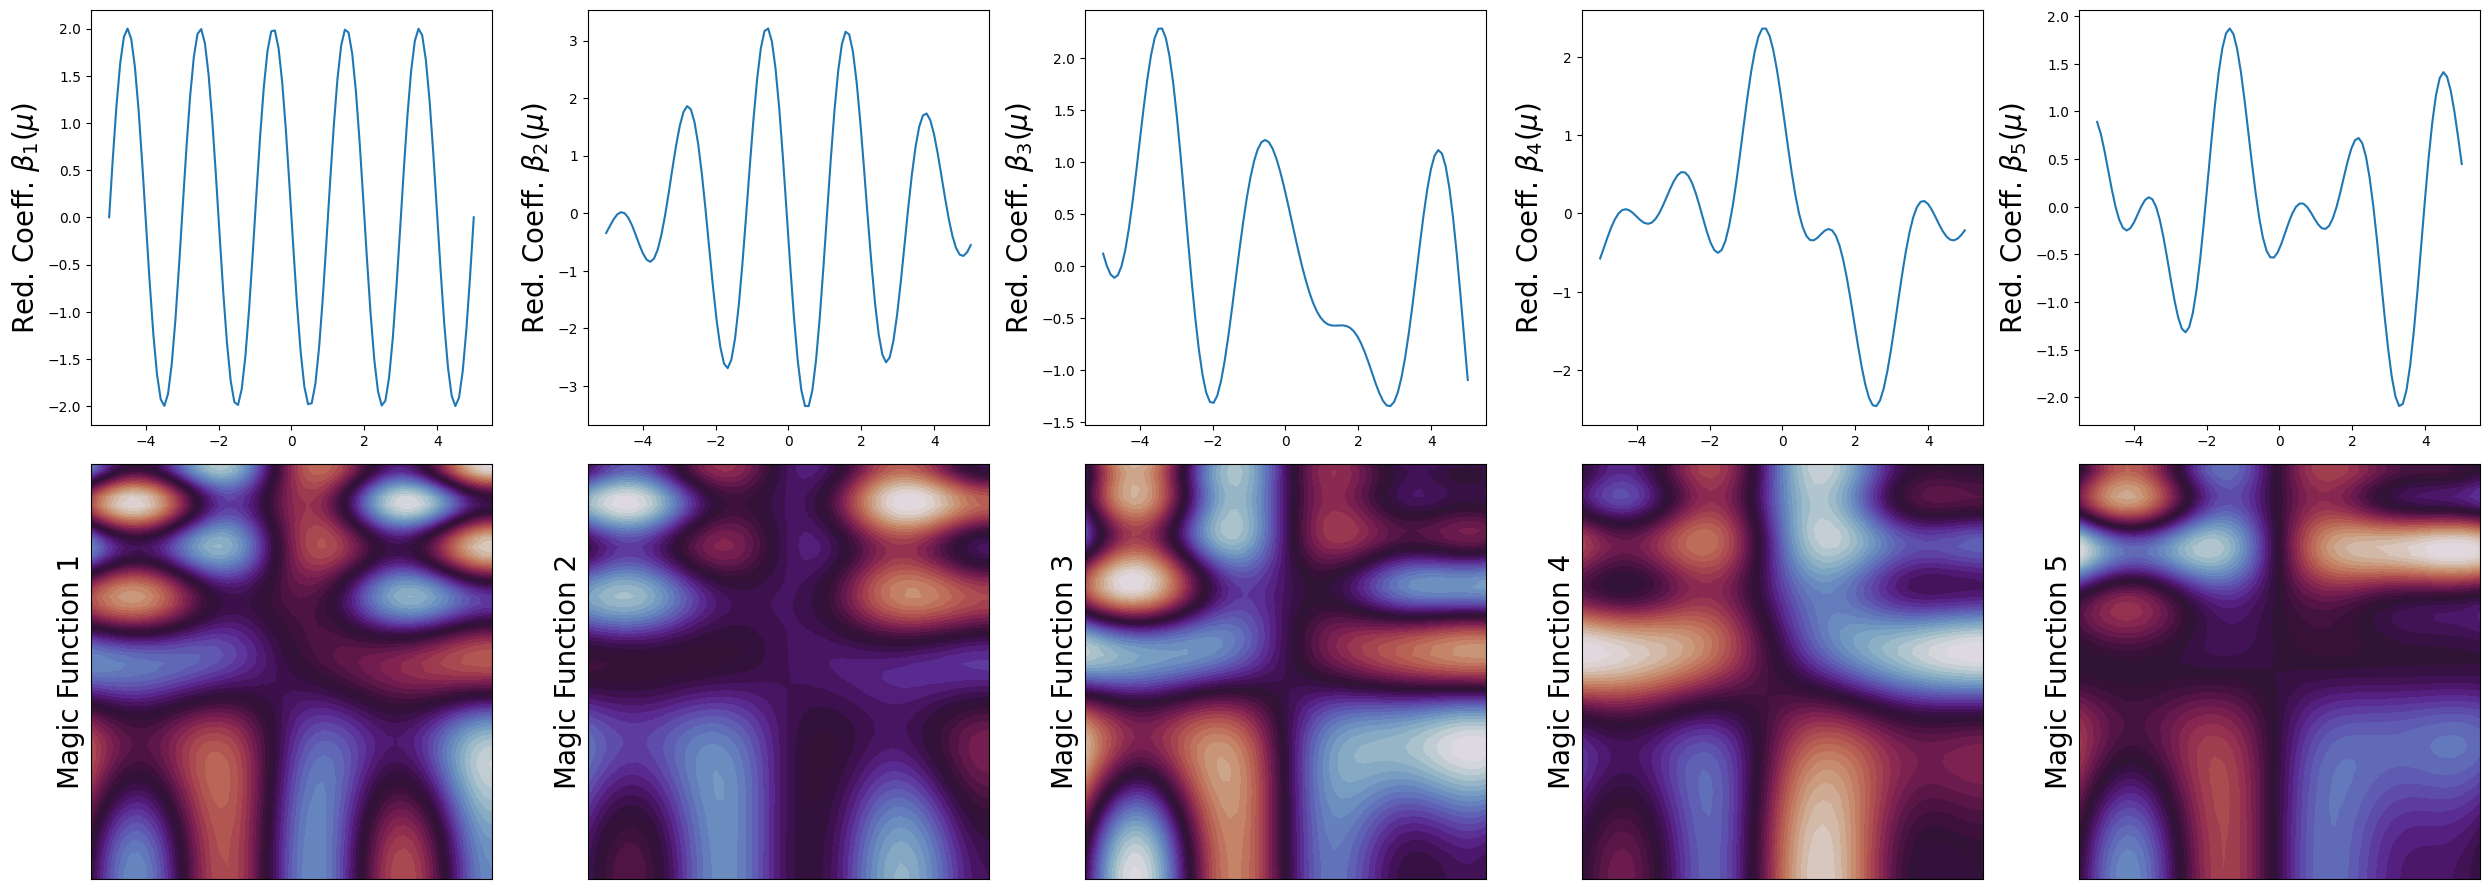

In [40]:
coeffs = eim.reduce(snapshots)

fig, axs = plt.subplots(2,5, figsize=(5 * 5, 4.5 * 2))

for ii in range(axs.shape[1]):
    
    axs[0, ii].plot(mu_values, coeffs[ii], '-')
    axs[1, ii].tricontourf(X, Y, eim.magic_functions[ii], levels=40, cmap='twilight')

    axs[0, ii].set_ylabel(r"Red. Coeff. $\beta_"+f"{ii+1}(\mu)$", fontsize=20)
    axs[1, ii].set_ylabel(f"Magic Function {ii+1}", fontsize=20)

for ax in axs[1]:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

## Comparison

Reconstruct the solution for a test parameter value and compare with the true solution.

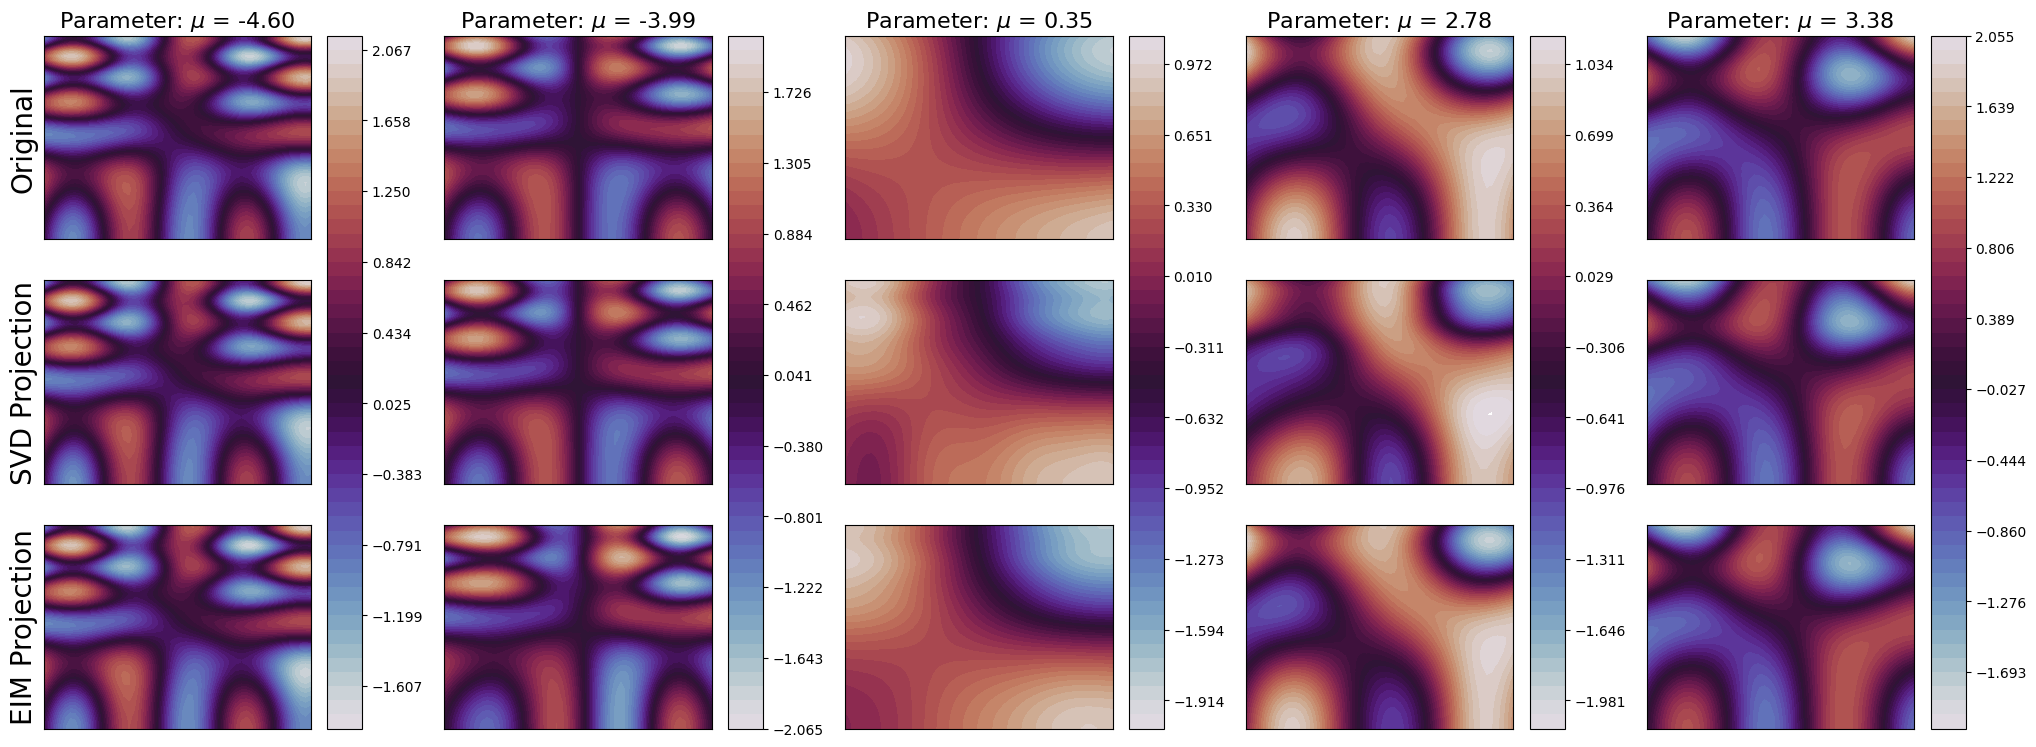

In [43]:
np.random.seed(42)
mu_to_test = np.sort(np.random.choice(test_mu, size=5, replace=False))

fig, axs = plt.subplots(3, len(mu_to_test), figsize=(5 * len(mu_to_test), 3 * 3))

for ii, mu in enumerate(mu_to_test):
    _snap = test_snaps(np.where(test_mu == mu)[0][0])

    # SVD reconstruction
    _coeff = svd.reduce(_snap, N = 10)
    _svd_recon = svd.reconstruct(_coeff)(0)

    # EIM reconstruction
    _measures = eim._get_measures(_snap, M=10)
    _eim_recon = eim.reconstruct(_measures)(0)

    levels = np.linspace(np.min(_snap) * 1.1, np.max(_snap) * 1.1, 50)
    c = axs[0, ii].tricontourf(X, Y, _snap, levels=levels, cmap='twilight')
    axs[1, ii].tricontourf(X, Y, _svd_recon, levels=levels, cmap='twilight')
    axs[2, ii].tricontourf(X, Y, _eim_recon, levels=levels, cmap='twilight')

    fig.colorbar(c, ax=axs[:, ii])

    axs[0, ii].set_title(f"Parameter: $\mu$ = {mu:.2f}", fontsize=16)

    if ii == 0:
        axs[0, ii].set_ylabel("Original", fontsize=20)
        axs[1, ii].set_ylabel("SVD Projection", fontsize=20)
        axs[2, ii].set_ylabel("EIM Projection", fontsize=20)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

fig.savefig("pyforce_demo_reconstruction.png", dpi=300, bbox_inches='tight')